In [ ]:
# ==========================================
# Phase 2 - Cell 1: 原始数据加载与白名单提纯
# 目的: 基于 HLTV Top 30 战队以及作者精选的具有高 AI 训练价值的现役选手进行第一步采样
# 输入: data/cs2_pro_detailed_RAW.csv (爬虫原始输出)
# 输出: 采样后的选手清单 (df_filtered)
# ==========================================
import pandas as pd

raw_csv = "data/cs2_pro_detailed_RAW.csv"
df = pd.read_csv(raw_csv)
print(f"📦 原始数据加载完毕！总基数人数: {len(df)}")

# 核心白名单：HLTV Top 1-30 核心战队 + 31-60 名中具备高设置参考价值的战队
# 逻辑: 确保分析结果代表当前 CS2 最高职业竞技水平
custom_whitelist =[
    # --- Top 30 核心 ---
    "Team Vitality", "Vitality", "FURIA Esports", "FURIA", "MOUZ", 
    "Falcons", "Team Falcons", "Natus Vincere", "NAVI", "Aurora Gaming", "Aurora", 
    "PARIVISION", "Team Spirit", "Spirit", "The MongolZ", "Astralis",
    "FaZe Clan", "FaZe", "FUT Esports", "FUT", "G2 Esports", "G2", 
    "3DMAX", "Legacy", "GamerLegion", "paiN Gaming", "paiN", 
    "HEROIC", "Team Liquid", "Liquid", "B8",
    "Ninjas in Pyjamas", "NIP", "9z Team", "9z", "NRG", 
    "Gentle Mates", "Monte", "TYLOO", "BC.Game", 
    "Passion UA", "BetBoom Team", "BetBoom", "HOTU",
    
    # ---精选高价值样本 (导师/名宿/特殊赛区代表) ---
    "100 Thieves", "100T",               # 澳洲老牌
    "Lynn Vision", "Lynn Vision Gaming", # 亚洲赛区核心
    "MIBR", "Imperial Esports", "Imperial", # 南美赛区核心
    "FlyQuest", "OG", "TDK", "fnatic", "EYEBALLERS"
]

# 执行过滤
df_filtered = df[df['Team'].notna() & df['Team'].isin(custom_whitelist)].copy()

print(f"\n✨ 提纯成功！当前数据集包含 {len(df_filtered)} 名顶级现役选手，具备极高模型训练价值。")
display(df_filtered[['Player', 'Team', 'DPI', 'Sensitivity', 'Resolution', 'Hz']].head(10))

📦 原始数据加载完毕！总人数: 872

✨ 过滤完成！我们提纯出了 185 名极具 AI 训练价值的现役选手！


,Player,Team,DPI,Sensitivity,Resolution,Hz,Scaling Mode
0,ZywOo,Team Vitality,400,2,1280x960,1000,Stretched
1,ropz,Team Vitality,400,1.77,1920x1080,2000,Native
2,flameZ,Team Vitality,400,3,1280x960,1000,Stretched
3,apEX,Team Vitality,400,1.91,1280x960,1000,Stretched
4,mezii,Team Vitality,400,2.2,1280x960,2000,Stretched
5,Jamppi,Team Vitality,800,0.42,1920x1080,1000,Stretched
6,donk,Team Spirit,800,1.25,1280x960,1000,Stretched
7,sh1ro,Team Spirit,800,1.04,1152x864,2000,Black Bars
8,magixx,Team Spirit,400,1.5,1280x960,2000,Stretched
9,zont1x,Team Spirit,1600,0.525,1024x768,1000,Stretched


In [ ]:
# ==========================================
# Phase 2 - Cell 2: 外科手术级数据转换与清洗
# 目的: 将爬虫抓取的原始字符串提纯为 AI 模型可读的数值特征 (eDPI, 分辨率拆解等)
# 输入: df_filtered (白名单选手数据)
# 输出: cs2_pro_2026_Active_Master.csv (Phase 2 核心成果)
# ==========================================
import pandas as pd
import numpy as np
import re

print("🧰 启动数据清洗流水线...")

# 1. 降维聚焦：只保留对 AI 建模有核心参考价值的特征
desired_columns =[
    'Player', 'Team', 'DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 
    'Hz', 'Resolution', 'Aspect Ratio', 'Scaling Mode'
]
actual_columns =[col for col in desired_columns if col in df_filtered.columns]
df_clean = df_filtered[actual_columns].copy()

# 2. 数值提纯：正则化提取字符串中的数字（处理 1,200 或 400dpi 等格式）
def clean_numeric_text(val):
    if pd.isna(val): return np.nan
    val_str = str(val).replace(',', '').replace(' ', '')
    match = re.search(r'[\d\.]+', val_str)
    return float(match.group()) if match else np.nan

numeric_cols = ['DPI', 'Sensitivity', 'eDPI', 'Zoom Sensitivity', 'Hz']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_numeric_text)

# 3. 逻辑补完：计算缺失的 eDPI (公式: DPI * Sensitivity)
if 'eDPI' in df_clean.columns:
    mask = df_clean['eDPI'].isna() & df_clean['DPI'].notna() & df_clean['Sensitivity'].notna()
    df_clean.loc[mask, 'eDPI'] = df_clean.loc[mask, 'DPI'] * df_clean.loc[mask, 'Sensitivity']

# 4. 特征拆解：分辨率字符串拆分为宽度和高度 (例如 "1280x960" -> 1280, 960)
if 'Resolution' in df_clean.columns:
    res_df = df_clean['Resolution'].astype(str).str.extract(r'(\d+)x(\d+)').astype(float)
    df_clean['Res_Width'] = res_df[0]
    df_clean['Res_Height'] = res_df[1]

# 5. 导出 Phase 2 成果，作为后续分析的 Master 基础表
master_csv = "data/cs2_pro_2026_Active_Master.csv"
df_clean.to_csv(master_csv, index=False, encoding='utf-8-sig')

print(f"✅ 清洗完毕！从脏数据中提纯出 {len(df_clean.columns)} 个黄金特征维度。")
print(f"💾 核心数据已存档: {master_csv}")
display(df_clean.head(5))

🧰 启动数据清洗流水线...
✅ 清洗完毕！从繁杂的脏数据中，提纯出了 12 列 AI 黄金特征！
💾 数据已保存至: cs2_pro_cleaned_features.csv


,Player,Team,DPI,Sensitivity,eDPI,Zoom Sensitivity,Hz,Resolution,Aspect Ratio,Scaling Mode,Res_Width,Res_Height
0,ZywOo,Team Vitality,400.0,2.00,800.0,1.0,1000.0,1280x960,4:3,Stretched,1280.0,960.0
1,ropz,Team Vitality,400.0,1.77,708.0,1.0,2000.0,1920x1080,16:9,Native,1920.0,1080.0
2,flameZ,Team Vitality,400.0,3.00,1200.0,1.1,1000.0,1280x960,4:3,Stretched,1280.0,960.0
3,apEX,Team Vitality,400.0,1.91,764.0,1.0,1000.0,1280x960,4:3,Stretched,1280.0,960.0
4,mezii,Team Vitality,400.0,2.20,880.0,1.0,2000.0,1280x960,4:3,Stretched,1280.0,960.0


📊 正在生成图表...


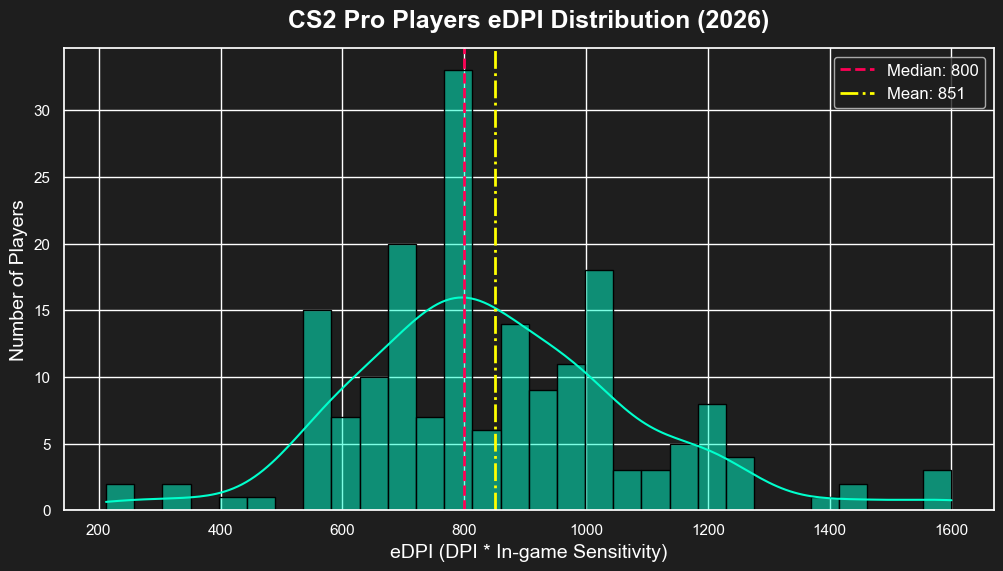


🌪️ 最高灵敏度玩家: woxic (Aurora) - eDPI: 1600.0
🐢 最低灵敏度玩家: ShahZaM (Team Liquid) - eDPI: 212.0


In [ ]:
# ==========================================
# Phase 3 - 可视化探索 (EDA)
# 目的: 在进入深度统计分析前，直观观察职业选手 eDPI 的分布规律
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 设置电竞全亮/暗黑主题
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#0a0a0a"})

plt.figure(figsize=(12, 6))
valid_edpi = df_clean[df_clean['eDPI'] < 2500]['eDPI'] # 排除极端值干扰

# 绘制 KDE 与直方图覆盖
sns.histplot(valid_edpi, bins=35, kde=True, color='#00E5FF', edgecolor='black')

# 标注中心趋势
median_v, mean_v = valid_edpi.median(), valid_edpi.mean()
plt.axvline(median_v, color='#FF4500', linestyle='--', label=f'中位数: {median_v:.0f}')
plt.axvline(mean_v, color='yellow', linestyle='-.', label=f'平均值: {mean_v:.0f}')

plt.title('CS2 Pro Players eDPI Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('eDPI (Sensitivity * DPI)', fontsize=12)
plt.ylabel('選手数量', fontsize=12)
plt.legend()
plt.show()

print(f"📊 分析发现: 职业选手中位 eDPI 约在 {median_v:.0f}，这是当前 CS2 的‘黄金灵敏度’。")

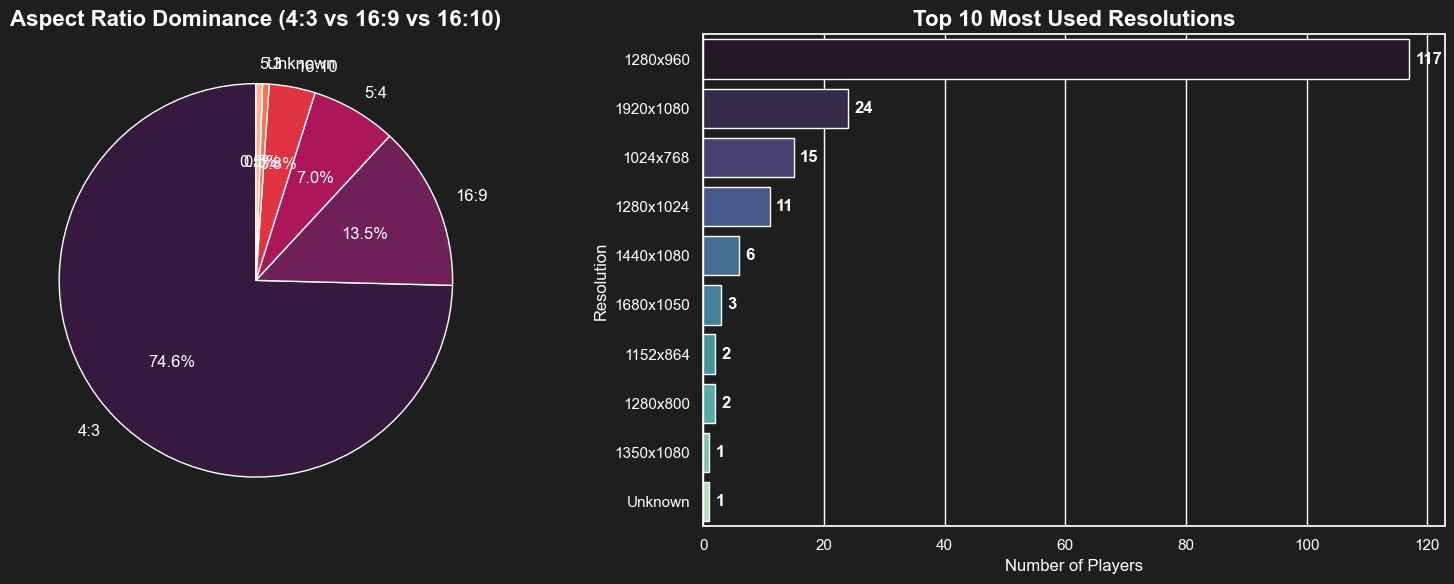

In [ ]:
# ==========================================
# Phase 3 - 分辨率与长宽比生态位分析
# 目的: 展示职业赛场上 4:3 拉伸与原生分辨率的对抗态势
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. 长宽比占比 (饼图)
aspect_counts = df_clean['Aspect Ratio'].value_counts()
axes[0].pie(aspect_counts, labels=aspect_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette('viridis'), startangle=140, 
            wedgeprops={'edgecolor': '#121212', 'linewidth': 2})
axes[0].set_title('主流长宽比分布', fontsize=15, fontweight='bold')

# 2. Top 10 分辨率排行 (水平条形图)
res_counts = df_clean['Resolution'].value_counts().head(10)
sns.barplot(x=res_counts.values, y=res_counts.index, ax=axes[1], palette='flare')
axes[1].set_title('最常被采用的分辨率 Top 10', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()